# Logistic Regression Training

In [1]:
# Pinned to requirements.txt. scikit-learn and librosa matter most: a different
# scikit-learn can fail to unpickle the model in the app, and a different librosa
# can produce different feature values.
!pip install -q scikit-learn==1.9.1 librosa==1.0.0 soundfile==0.14.0 joblib==1.6.0

print()
print("If Colab shows a 'Restart runtime' button above, click it, then carry on")
print("from the Drive mount cell. Do not run this install cell again.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.

If Colab shows a 'Restart runtime' button above, click it, then carry on
from the Drive mount cell. Do not run this install cell again.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

PROJECT_PATH = '/content/drive/MyDrive/SonicSentinel'

In [4]:
import os
import sys

if not os.path.isdir(PROJECT_PATH):
    raise RuntimeError(
        f"PROJECT_PATH does not exist: {PROJECT_PATH}\n"
        "Check the folder name in your Drive and fix PROJECT_PATH in the cell above."
    )

if not os.path.isfile(os.path.join(PROJECT_PATH, 'feature_extraction', 'features.py')):
    raise RuntimeError(
        f"{PROJECT_PATH} does not look like the project folder.\n"
        "It must contain app.py, config/, feature_extraction/ and src/."
    )

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)


try:
    import feature_extraction.features as features_module
    from feature_extraction.features import FEATURE_NAMES, FEATURE_VECTOR_LENGTH
    from config.config import CLASSES, PYTHON_MODELS
    from src.training import run_training
except Exception as error:
    raise RuntimeError(
        "Could not import the project modules from PROJECT_PATH.\n"
        "Check that the whole project folder was uploaded to Drive, including "
        "config/, feature_extraction/, audio_preprocessing/ and src/."
    ) from error


if not os.path.abspath(features_module.__file__).startswith(os.path.abspath(PROJECT_PATH)):
    raise RuntimeError(
        f"features.py was imported from {features_module.__file__}, "
        f"not from {PROJECT_PATH}. Fix sys.path before training."
    )

print("imported the project modules from", PROJECT_PATH)
print("feature module:", features_module.__file__)
print("feature vector length:", FEATURE_VECTOR_LENGTH)
print("classes:", len(CLASSES))

/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


imported the project modules from /content/drive/MyDrive/SonicSentinel
feature module: /content/drive/MyDrive/SonicSentinel/feature_extraction/features.py
feature vector length: 215
classes: 10


In [5]:
from sklearn.linear_model import LogisticRegression

MODEL_NAME = "logistic_regression"

estimator = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)

# saga was dropped: it is very slow on this many rows and lbfgs handles the
# multinomial case just as well here.
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
}

In [6]:

model = run_training(MODEL_NAME, estimator, param_grid)

Dataset on disk
  dataset folder: /content/drive/MyDrive/SonicSentinel/audio_dataset

  class                               training  augmented training          validation             testing
  machinery_fault                          210                 630                  45                  45
  glass_breaking                           210                 630                  45                  45
  alarm_siren                              210                 630                  45                  45
  vehicle_horn                             210                 630                  45                  45
  animal_sound                             210                 630                  45                  45
  gunshot                                  210                 630                  45                  45
  panic_scream                             210                 630                  45                  45
  aggression                               210            

/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  machinery_fault: 50/210 files
  machinery_fault: 100/210 files
  machinery_fault: 150/210 files
  machinery_fault: 200/210 files
machinery_fault -> 210/210 files done
  glass_breaking: 50/210 files
  glass_breaking: 100/210 files
  glass_breaking: 150/210 files
  glass_breaking: 200/210 files
glass_breaking -> 210/210 files done
  alarm_siren: 50/210 files
  alarm_siren: 100/210 files
  alarm_siren: 150/210 files
  alarm_siren: 200/210 files
alarm_siren -> 210/210 files done
  vehicle_horn: 50/210 files
  vehicle_horn: 100/210 files
  vehicle_horn: 150/210 files
  vehicle_horn: 200/210 files
vehicle_horn -> 210/210 files done
  animal_sound: 50/210 files
  animal_sound: 100/210 files
  animal_sound: 150/210 files
  animal_sound: 200/210 files
animal_sound -> 210/210 files done
  gunshot: 50/210 files
  gunshot: 100/210 files
  gunshot: 150/210 files
  gunshot: 200/210 files
gunshot -> 210/210 files done
  panic_scream: 50/210 files
  panic_scream: 100/210 files
  panic_scream: 150/21

/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


machinery_fault -> 45/45 files done
glass_breaking -> 45/45 files done
alarm_siren -> 45/45 files done
vehicle_horn -> 45/45 files done
animal_sound -> 45/45 files done
gunshot -> 45/45 files done
panic_scream -> 45/45 files done
aggression -> 45/45 files done
  person_asking_help: 50/54 files
person_asking_help -> 54/54 files done
background_noise -> 45/45 files done
cached 459 rows to /content/drive/MyDrive/SonicSentinel/data/metadata/val_features.csv

building test features from /content/drive/MyDrive/SonicSentinel/audio_dataset/testing
machinery_fault -> 45/45 files done
glass_breaking -> 45/45 files done
alarm_siren -> 45/45 files done


...

  noise sd=0.005: accuracy 0.6247


/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  noise sd=0.02: accuracy 0.5978


/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:105: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  noise sd=0.05: accuracy 0.5079
saved model to /content/drive/MyDrive/SonicSentinel/python_models/logistic_regression_model.pkl
saved scaler to /content/drive/MyDrive/SonicSentinel/python_models/logistic_regression_scaler.pkl
saved label encoder to /content/drive/MyDrive/SonicSentinel/python_models/label_encoder.pkl

saved metrics to /content/drive/MyDrive/SonicSentinel/reports/logistic_regression_metrics.json

test results
  accuracy  0.6809
  macro f1  0.6812
  critical-class recall
    Gunshot                  0.7556   <- below the 0.85 target
    Panic Scream             0.7556   <- below the 0.85 target
    Person Asking for Help   0.75   <- below the 0.85 target
    Aggression               0.8889
    Glass Breaking           0.8444   <- below the 0.85 target
saved plot /content/drive/MyDrive/SonicSentinel/reports/plots/logistic_regression_overall_metrics.png
saved plot /content/drive/MyDrive/SonicSentinel/reports/plots/logistic_regression_per_class_metrics.png
saved plot /conte

In [7]:
# What this notebook wrote to Drive.
import os

for folder, names in [
    ('python_models', [
        PYTHON_MODELS[MODEL_NAME]['model_file'],
        PYTHON_MODELS[MODEL_NAME]['scaler_file'],
        'label_encoder.pkl',
    ]),
    ('reports', [PYTHON_MODELS[MODEL_NAME]['metrics_file']]),
]:
    for name in names:
        path = os.path.join(PROJECT_PATH, folder, name)
        state = 'saved' if os.path.exists(path) else 'MISSING'
        print(f"{state:8} {folder}/{name}")

print()
print("Download those files from Drive and put them in the same folders in the")
print("project, then set ACTIVE_PYTHON_MODEL in config/config.py to the model")
print("you picked.")

saved    python_models/logistic_regression_model.pkl
saved    python_models/logistic_regression_scaler.pkl
saved    python_models/label_encoder.pkl
saved    reports/logistic_regression_metrics.json

Download those files from Drive and put them in the same folders in the
project, then set ACTIVE_PYTHON_MODEL in config/config.py to the model
you picked.


logistic_regression_confusion_matrix.png


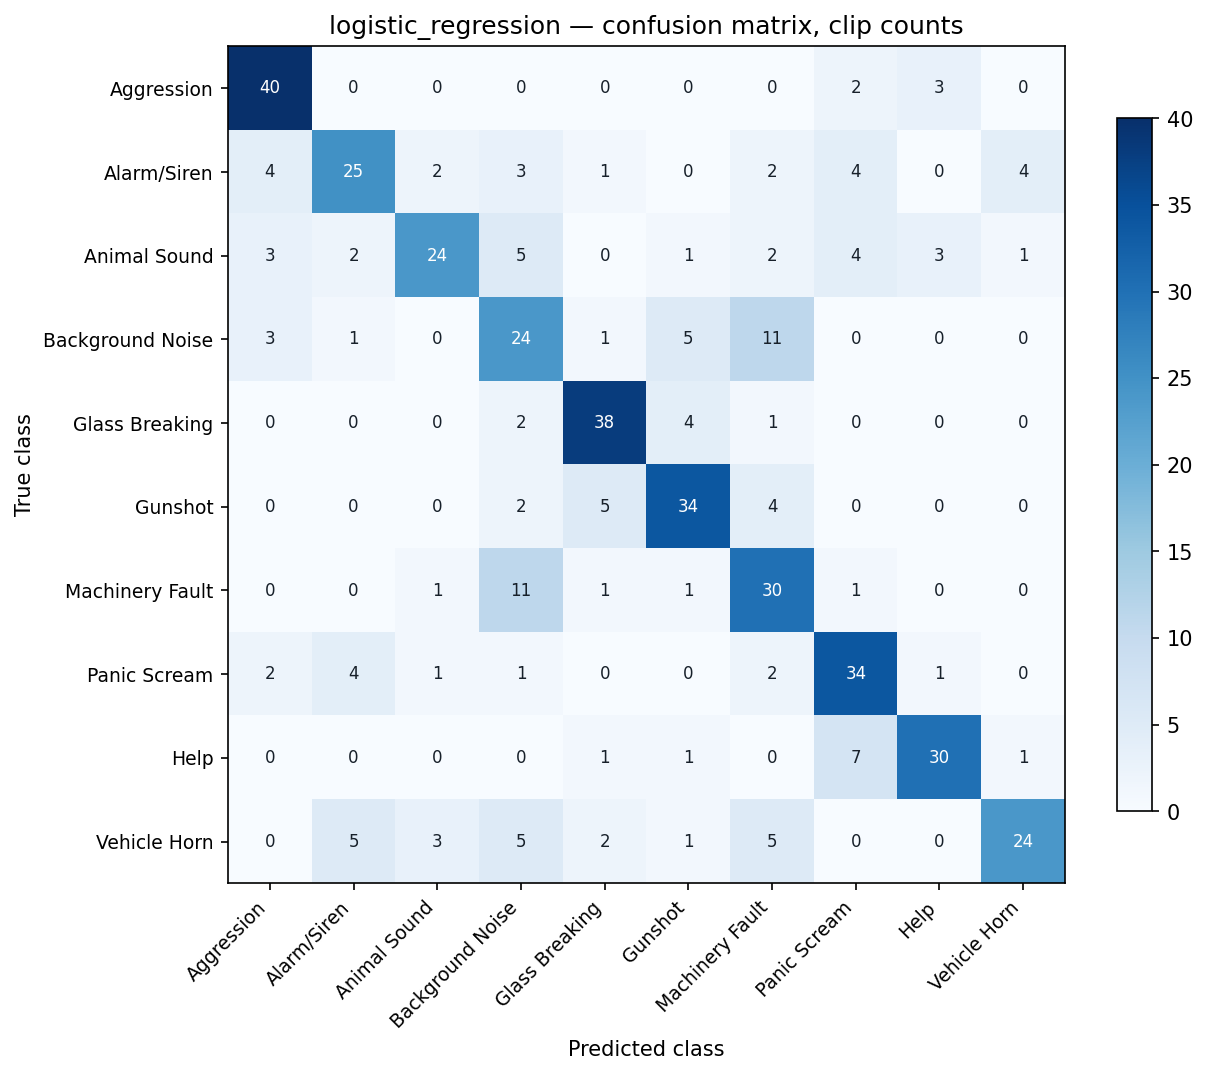

logistic_regression_confusion_matrix_normalised.png


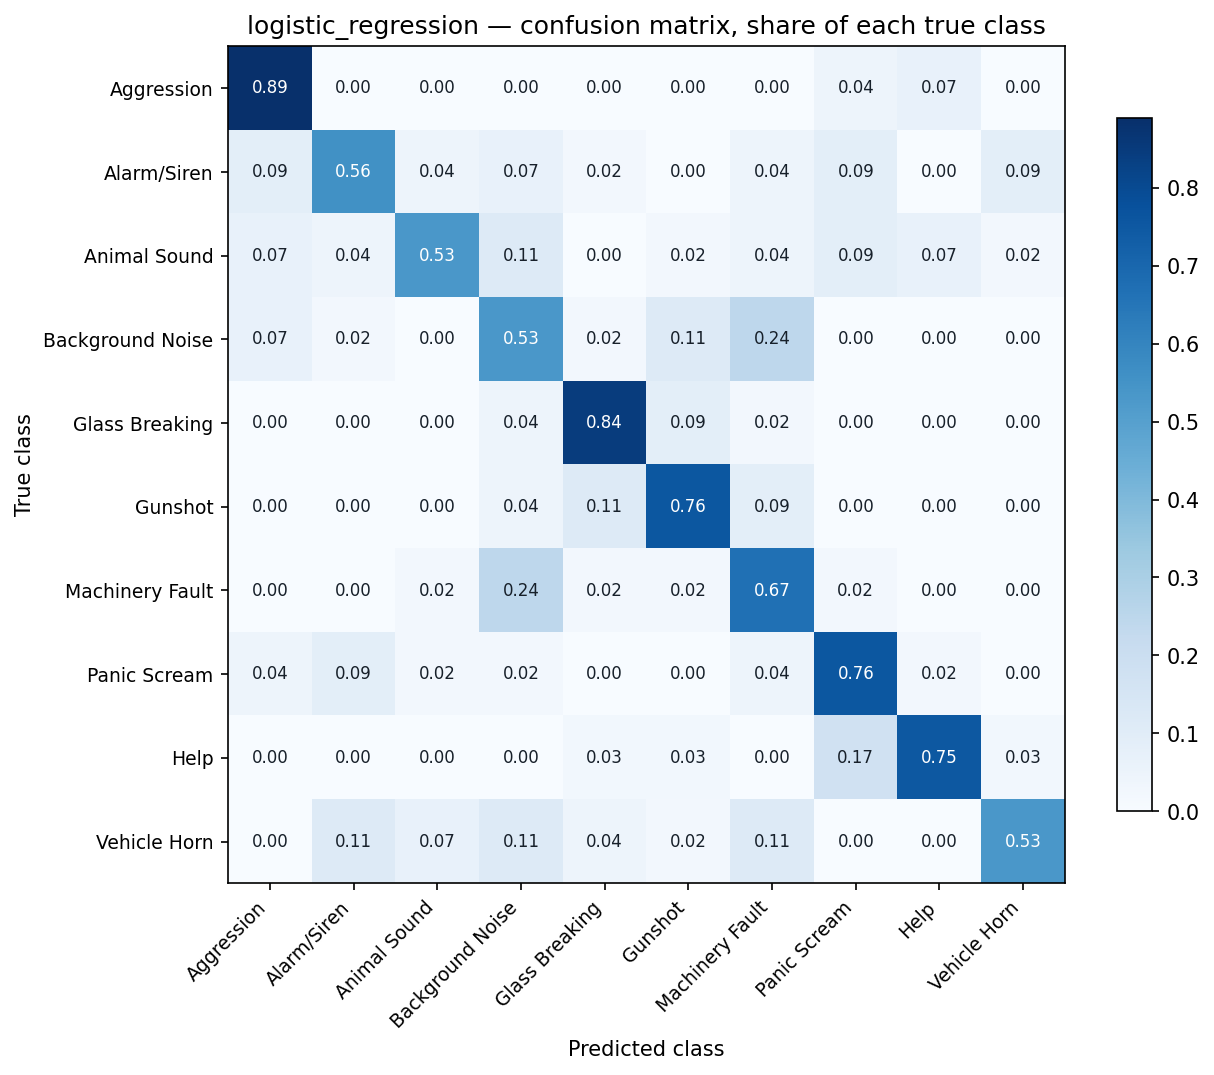

logistic_regression_critical_recall.png


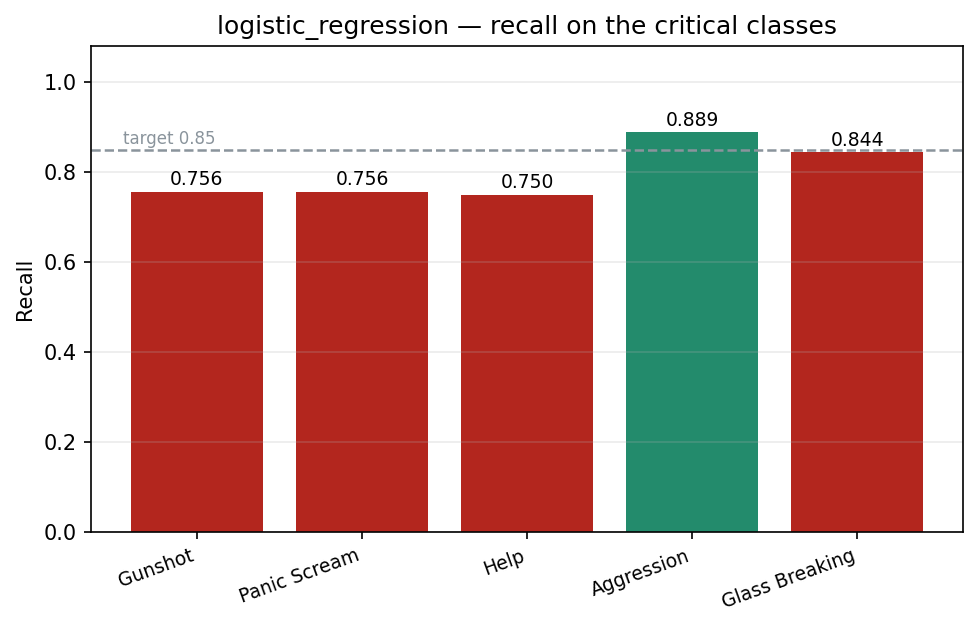

logistic_regression_noise_robustness.png


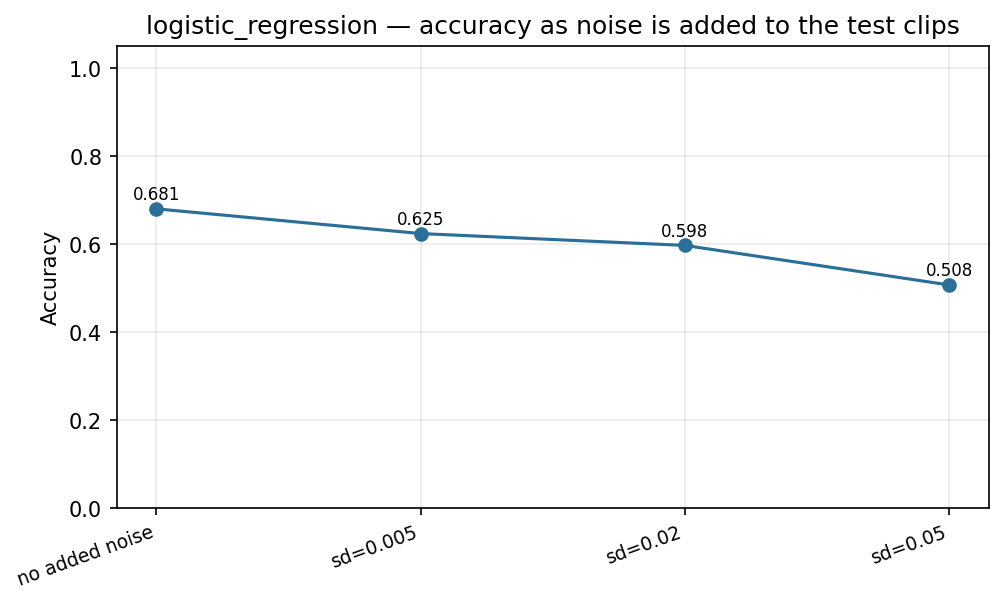

logistic_regression_overall_metrics.png


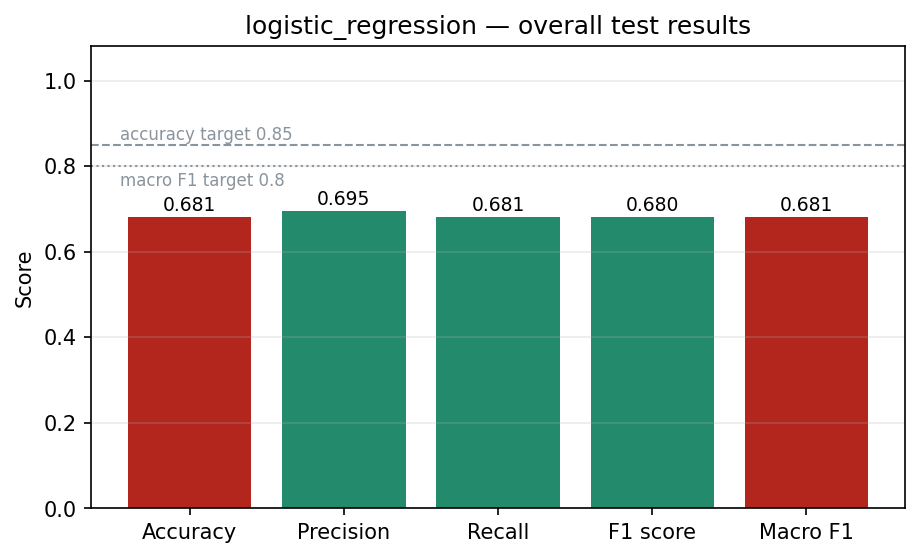

logistic_regression_per_class_metrics.png


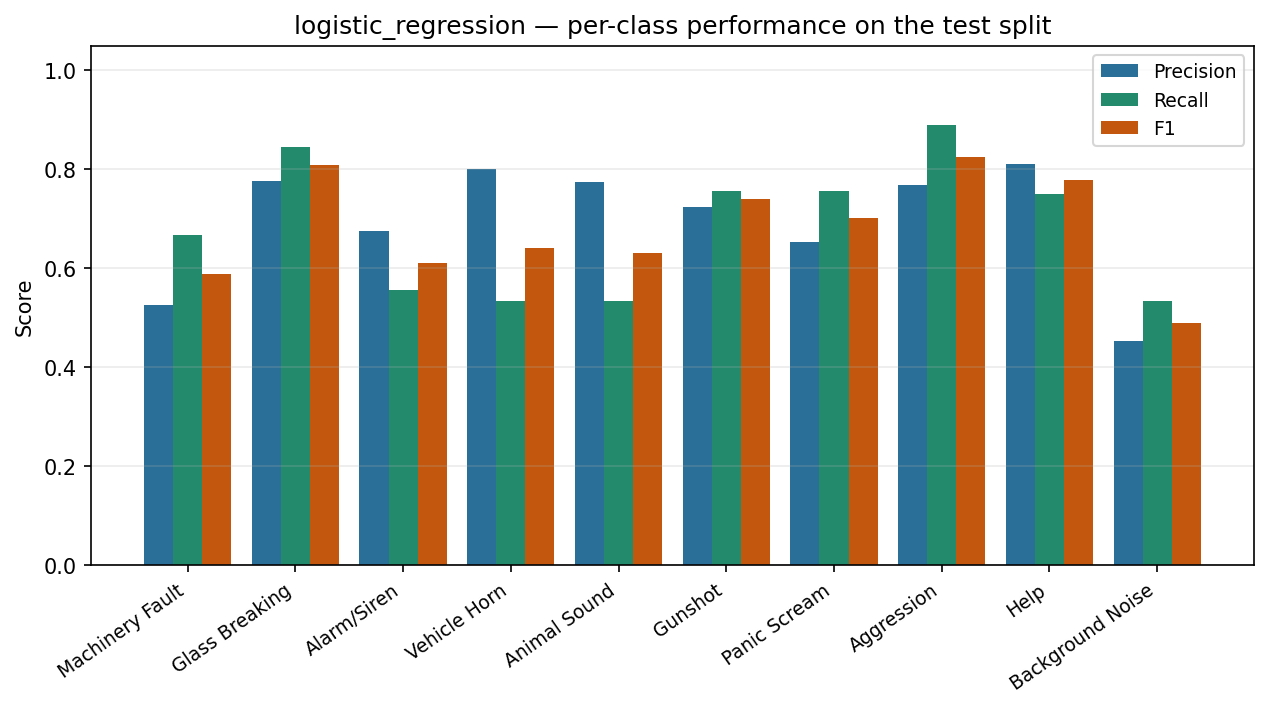

logistic_regression_validation_vs_test.png


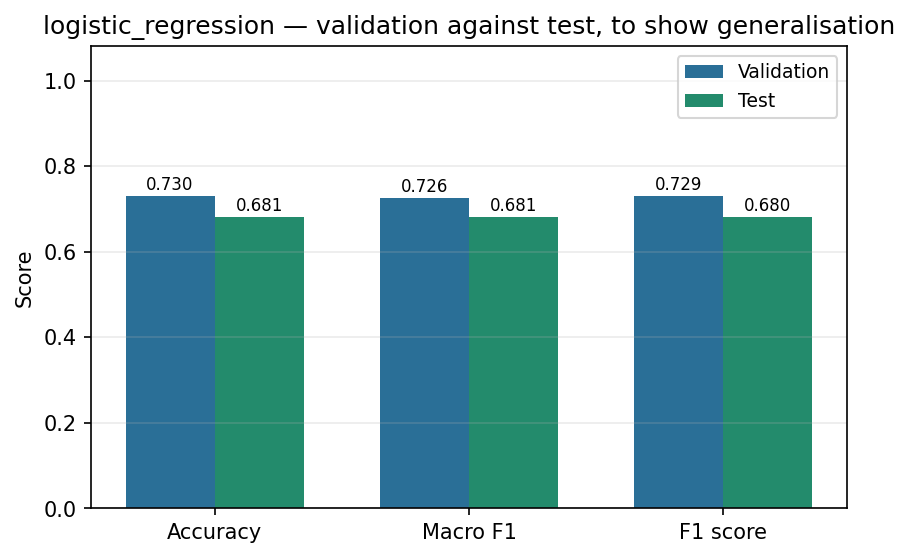

dataset_distribution.png


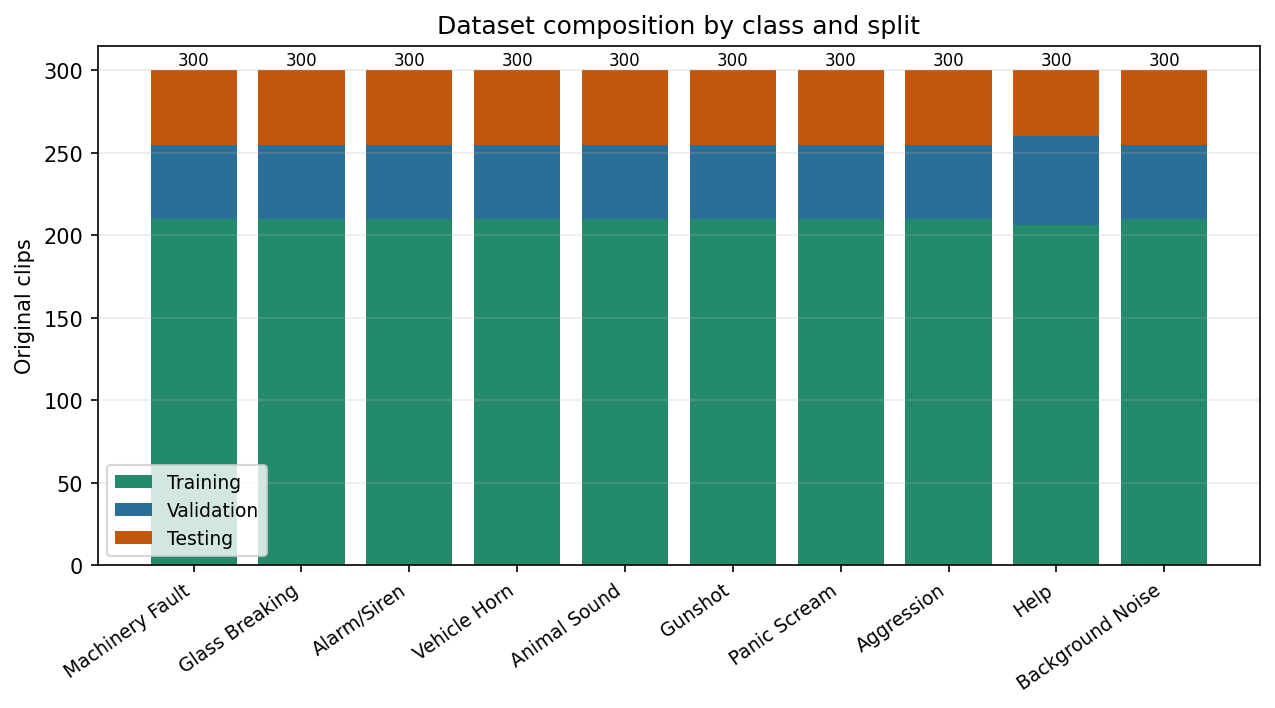

example_spectrograms.png


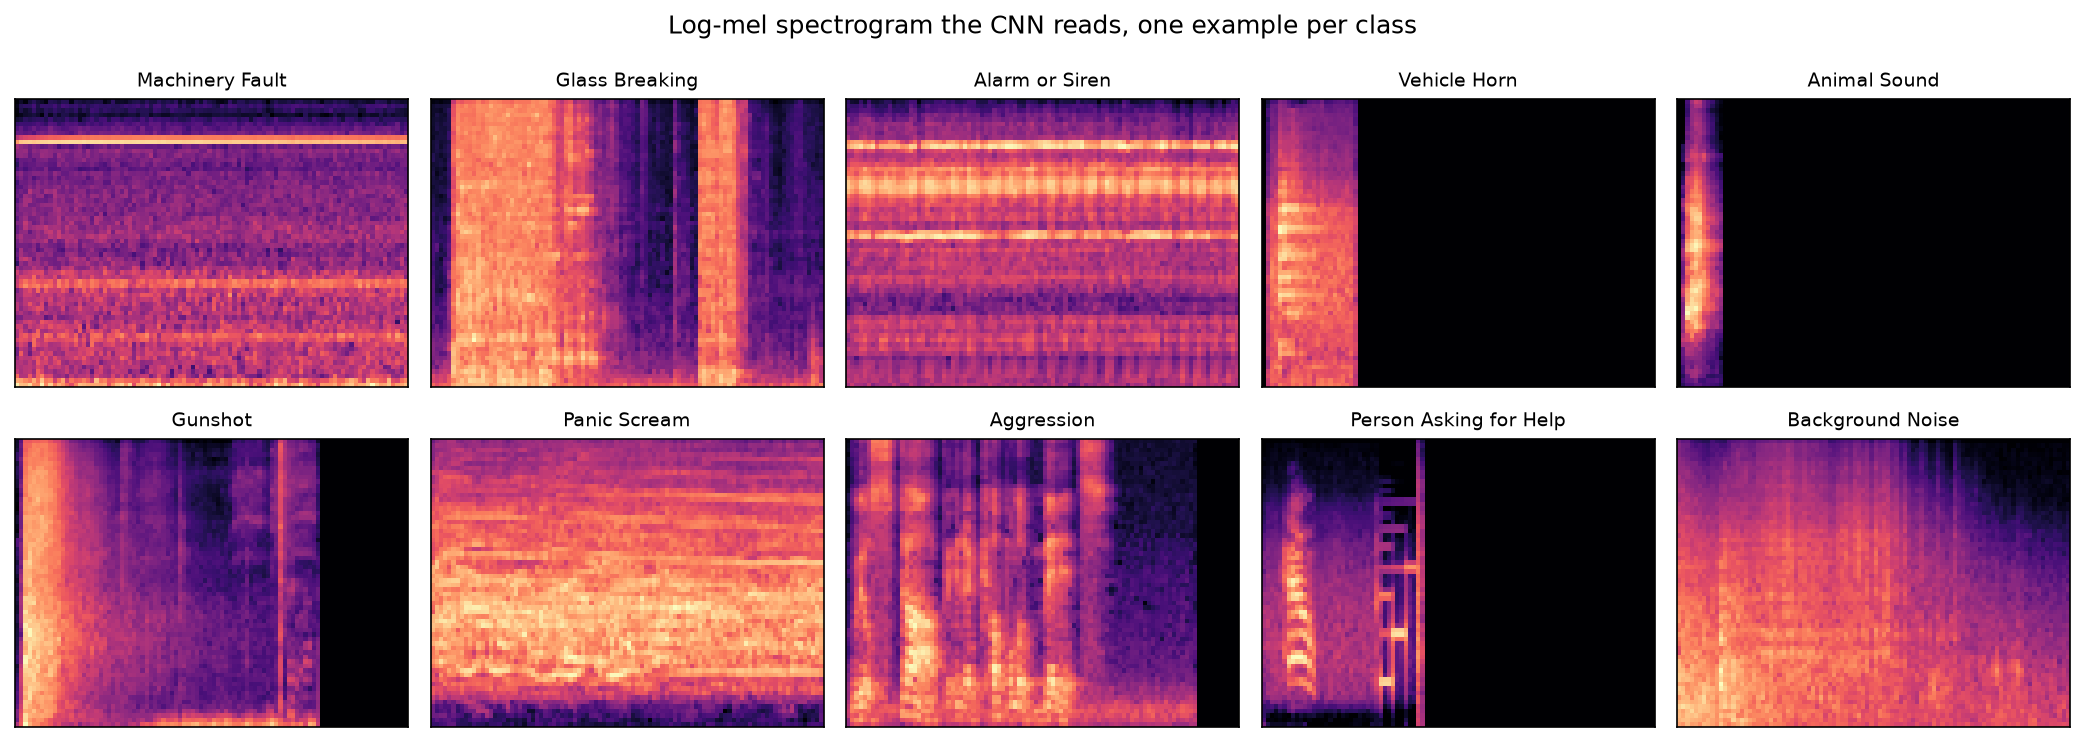

model_comparison.png


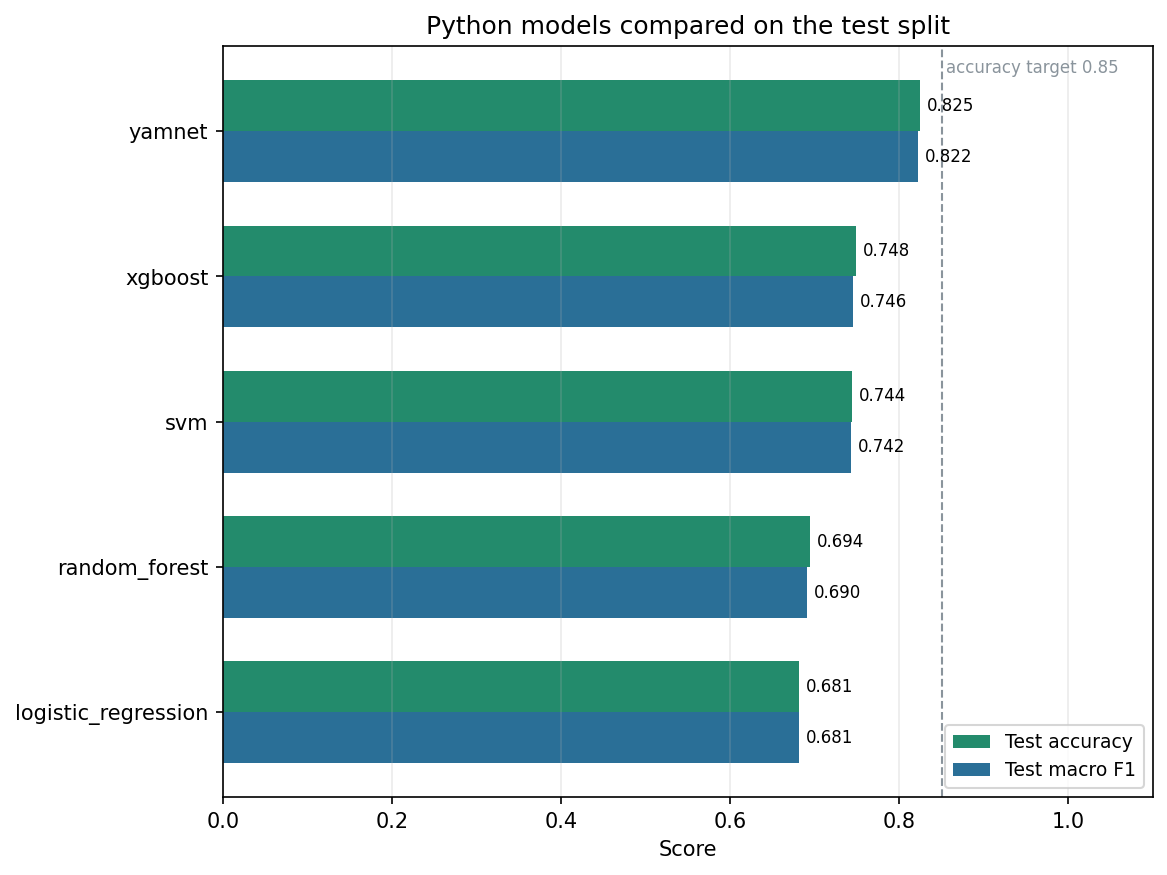

In [8]:
# The figures the training run wrote, shown here so they can be saved for the
# report. They are also on Drive in reports/plots/.
import glob
import os

from IPython.display import Image, display

pattern = os.path.join(PROJECT_PATH, "reports", "plots", "*.png")
paths = sorted(glob.glob(pattern))

mine = [p for p in paths if os.path.basename(p).startswith(MODEL_NAME)]
shared = [p for p in paths if os.path.basename(p) in
          ("model_comparison.png", "dataset_distribution.png", "example_spectrograms.png")]

if not paths:
    print("No plots found. Did the training cell finish?")

for path in mine + shared:
    print(os.path.basename(path))
    display(Image(filename=path))